In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
# ========== PREPROCESSING OF DATASET ============
"""
Preprocess MRI-to-CT dataset on Kaggle.
Reads patient folders under /Task1/brain,
checks for .nii files (mr.nii, ct.nii, mask.nii),
and builds a list of patient records.
"""

import gzip
import shutil
from pathlib import Path
from tqdm import tqdm

# --- 1. Configuration ---
# Base path to the extracted dataset folder (brain anatomy only)
EXTRACT_PATH = Path("/kaggle/input/mri-to-ct-project/Task1/brain")

# --- 2. Find all patient directories ---
print(f"\n--> Searching for patient directories in {EXTRACT_PATH}")
patient_dirs = [p for p in EXTRACT_PATH.iterdir() if p.is_dir()]

all_patients_data = []

# --- 3. Process patient data ---
print("\n--> Finding patient scans and decompressing .nii.gz if any...")

for patient_dir in tqdm(patient_dirs, desc="Processing Patients"):
    mr_gz_path = patient_dir / 'mr.nii.gz'
    ct_gz_path = patient_dir / 'ct.nii.gz'

    mr_path = patient_dir / 'mr.nii'
    ct_path = patient_dir / 'ct.nii'
    mask_path = patient_dir / 'mask.nii'

    # Decompress mr.nii.gz to mr.nii if needed
    if mr_gz_path.exists() and not mr_path.exists():
        with gzip.open(mr_gz_path, 'rb') as f_in, open(mr_path, 'wb') as f_out:
            shutil.copyfileobj(f_in, f_out)

    # Decompress ct.nii.gz to ct.nii if needed
    if ct_gz_path.exists() and not ct_path.exists():
        with gzip.open(ct_gz_path, 'rb') as f_in, open(ct_path, 'wb') as f_out:
            shutil.copyfileobj(f_in, f_out)

    # Collect patient record if files exist
    record = {
        'id': patient_dir.name,
        'path': str(patient_dir),
        'mr_path': str(mr_path) if mr_path.exists() else None,
        'ct_path': str(ct_path) if ct_path.exists() else None,
        'mask_path': str(mask_path) if mask_path.exists() else None,
        'anatomy': 'brain',  # Update if adding pelvis or others
    }

    all_patients_data.append(record)

# --- 4. Final summary ---
print("\n" + "="*50)
print("Preprocessing complete!")
print(f"Total patient records found: {len(all_patients_data)}")
if all_patients_data:
    print("\nExample patient record:")
    print(all_patients_data[0])
print("="*50)



--> Searching for patient directories in /kaggle/input/mri-to-ct-project/Task1/brain

--> Finding patient scans and decompressing .nii.gz if any...


Processing Patients: 100%|██████████| 181/181 [00:01<00:00, 131.22it/s]


Preprocessing complete!
Total patient records found: 181

Example patient record:
{'id': '1BC090', 'path': '/kaggle/input/mri-to-ct-project/Task1/brain/1BC090', 'mr_path': '/kaggle/input/mri-to-ct-project/Task1/brain/1BC090/mr.nii', 'ct_path': '/kaggle/input/mri-to-ct-project/Task1/brain/1BC090/ct.nii', 'mask_path': '/kaggle/input/mri-to-ct-project/Task1/brain/1BC090/mask.nii', 'anatomy': 'brain'}


In [2]:
# =============  ENHANCED BRAIN SLICING ==========================
            
"""
Processes ONLY brain scans from Task1 on Kaggle
and saves only useful slices with meaningful anatomical content.
"""

import nibabel as nib
import numpy as np
import cv2
from pathlib import Path
from tqdm import tqdm
import os
import shutil
import re

# --- 1. Configuration ---
INPUT_DATA_PATH = Path('/kaggle/input/mri-to-ct-project/Task1/brain')  # Corrected path to match your dataset
OUTPUT_SLICES_PATH = Path('/kaggle/working/processed_2D_BRAIN_slices')

# Check input path existence early
if not INPUT_DATA_PATH.exists():
    raise FileNotFoundError(f"Input data path {INPUT_DATA_PATH} does not exist. Check your dataset extraction.")

# --- !! CLEANUP FIRST !! ---
if OUTPUT_SLICES_PATH.exists():
    print("--> Removing old 'processed_slices' directory for fresh processing...")
    shutil.rmtree(OUTPUT_SLICES_PATH)
    print("Cleanup complete.")

# Create output directories
PATH_TRAIN_A = OUTPUT_SLICES_PATH / 'trainA'  # MRI
PATH_TRAIN_B = OUTPUT_SLICES_PATH / 'trainB'  # CT
PATH_TRAIN_A.mkdir(parents=True, exist_ok=True)
PATH_TRAIN_B.mkdir(parents=True, exist_ok=True)
print(f"Output directories created at {PATH_TRAIN_A} and {PATH_TRAIN_B}")

# --- Helper functions ---

def sanitize_filename(name):
    """Sanitize strings for safe filenames."""
    return re.sub(r'[^a-zA-Z0-9_-]', '_', name)

def normalize_and_convert_to_uint8(image_data):
    """Normalize image data to 0-255 and convert to uint8."""
    lower_bound, upper_bound = np.percentile(image_data, [0.5, 99.5])
    clipped_data = np.clip(image_data, lower_bound, upper_bound)
    if upper_bound == lower_bound:
        return np.zeros_like(clipped_data, dtype=np.uint8)
    normalized_data = 255 * (clipped_data - lower_bound) / (upper_bound - lower_bound)
    return normalized_data.astype(np.uint8)

def is_useful_brain_slice(mri_slice, ct_slice,
                         mean_threshold=15,
                         variance_threshold=100,
                         brain_tissue_ratio=0.3):
    """Check if slice contains meaningful anatomical content."""
    if mri_slice.mean() < mean_threshold or ct_slice.mean() < mean_threshold:
        return False
    if mri_slice.var() < variance_threshold or ct_slice.var() < variance_threshold:
        return False

    mri_tissue = np.sum(mri_slice > 20) / mri_slice.size
    ct_tissue = np.sum(ct_slice > 20) / ct_slice.size
    if mri_tissue < brain_tissue_ratio or ct_tissue < brain_tissue_ratio:
        return False
    if np.ptp(mri_slice) < 30 or np.ptp(ct_slice) < 30:
        return False
    return True

def get_middle_slice_range(total_slices, coverage=0.6):
    """Focus on middle portion of brain with most anatomical detail."""
    start = int(total_slices * (1 - coverage) / 2)
    end = int(total_slices * (1 + coverage) / 2)
    return start, end

# --- Main Processing Logic ---
print("\n--> Starting enhanced 3D to 2D slice conversion for BRAIN DATA ONLY...")
print("Filter criteria: Mean >15, Variance >100, Brain tissue ratio >30%")

# Look for patient directories directly in the brain folder
patient_dirs = [p for p in INPUT_DATA_PATH.iterdir() if p.is_dir()]
mri_files = []

for patient_dir in patient_dirs:
    mr_file = patient_dir / 'mr.nii'
    if mr_file.exists():
        mri_files.append(mr_file)

if not mri_files:
    print("\n❌ CRITICAL ERROR: No brain 'mr.nii' files found.")
    print("Please ensure your data structure is correct.")
else:
    print(f"Found {len(mri_files)} paired BRAIN scans to process.")

    slices_saved_count = 0
    total_slices_processed = 0
    skipped_volumes = 0

    for mri_path in tqdm(mri_files, desc="Processing Brain Volumes", disable=False):
        ct_path = mri_path.with_name('ct.nii')
        if not ct_path.exists():
            skipped_volumes += 1
            continue

        try:
            mri_data = nib.load(mri_path).get_fdata()
            ct_data = nib.load(ct_path).get_fdata()

            total_slices = mri_data.shape[2]
            start_idx, end_idx = get_middle_slice_range(total_slices)

            for i in range(start_idx, end_idx):
                total_slices_processed += 1

                mri_slice = normalize_and_convert_to_uint8(mri_data[:, :, i])
                ct_slice = normalize_and_convert_to_uint8(ct_data[:, :, i])

                if is_useful_brain_slice(mri_slice, ct_slice):
                    filename = f"{sanitize_filename(mri_path.parent.name)}_slice_{i:03d}.png"
                    cv2.imwrite(str(PATH_TRAIN_A / filename), mri_slice)
                    cv2.imwrite(str(PATH_TRAIN_B / filename), ct_slice)
                    slices_saved_count += 1

        except Exception as e:
            print(f"Error processing {mri_path}: {e}")
            skipped_volumes += 1

    # --- Summary ---
    print("\n" + "="*70)
    print("Enhanced Brain-Only Slice Processing Complete!")
    print("="*70)
    print(f"✅ Volumes processed: {len(mri_files) - skipped_volumes}")
    print(f"⚠️  Volumes skipped: {skipped_volumes}")
    print(f"📊 Total slices examined: {total_slices_processed}")
    print(f"💾 Useful slices saved: {slices_saved_count}")
    if total_slices_processed > 0:
        print(f"📈 Selection ratio: {slices_saved_count/total_slices_processed*100:.1f}%")
    print("="*70)

    if slices_saved_count > 0:
        print("\n🎯 Dataset quality improved and ready for training!")
    else:
        print("\n⚠️ No slices met the criteria. Consider lowering thresholds.")


Output directories created at /kaggle/working/processed_2D_BRAIN_slices/trainA and /kaggle/working/processed_2D_BRAIN_slices/trainB

--> Starting enhanced 3D to 2D slice conversion for BRAIN DATA ONLY...
Filter criteria: Mean >15, Variance >100, Brain tissue ratio >30%
Found 180 paired BRAIN scans to process.


Processing Brain Volumes: 100%|██████████| 180/180 [03:41<00:00,  1.23s/it]


Enhanced Brain-Only Slice Processing Complete!
✅ Volumes processed: 180
⚠️  Volumes skipped: 0
📊 Total slices examined: 20749
💾 Useful slices saved: 17669
📈 Selection ratio: 85.2%

🎯 Dataset quality improved and ready for training!


✅ Brain-only dataset found. Starting EDA...
Analyzing sample pair: 1BA032_slice_099.png


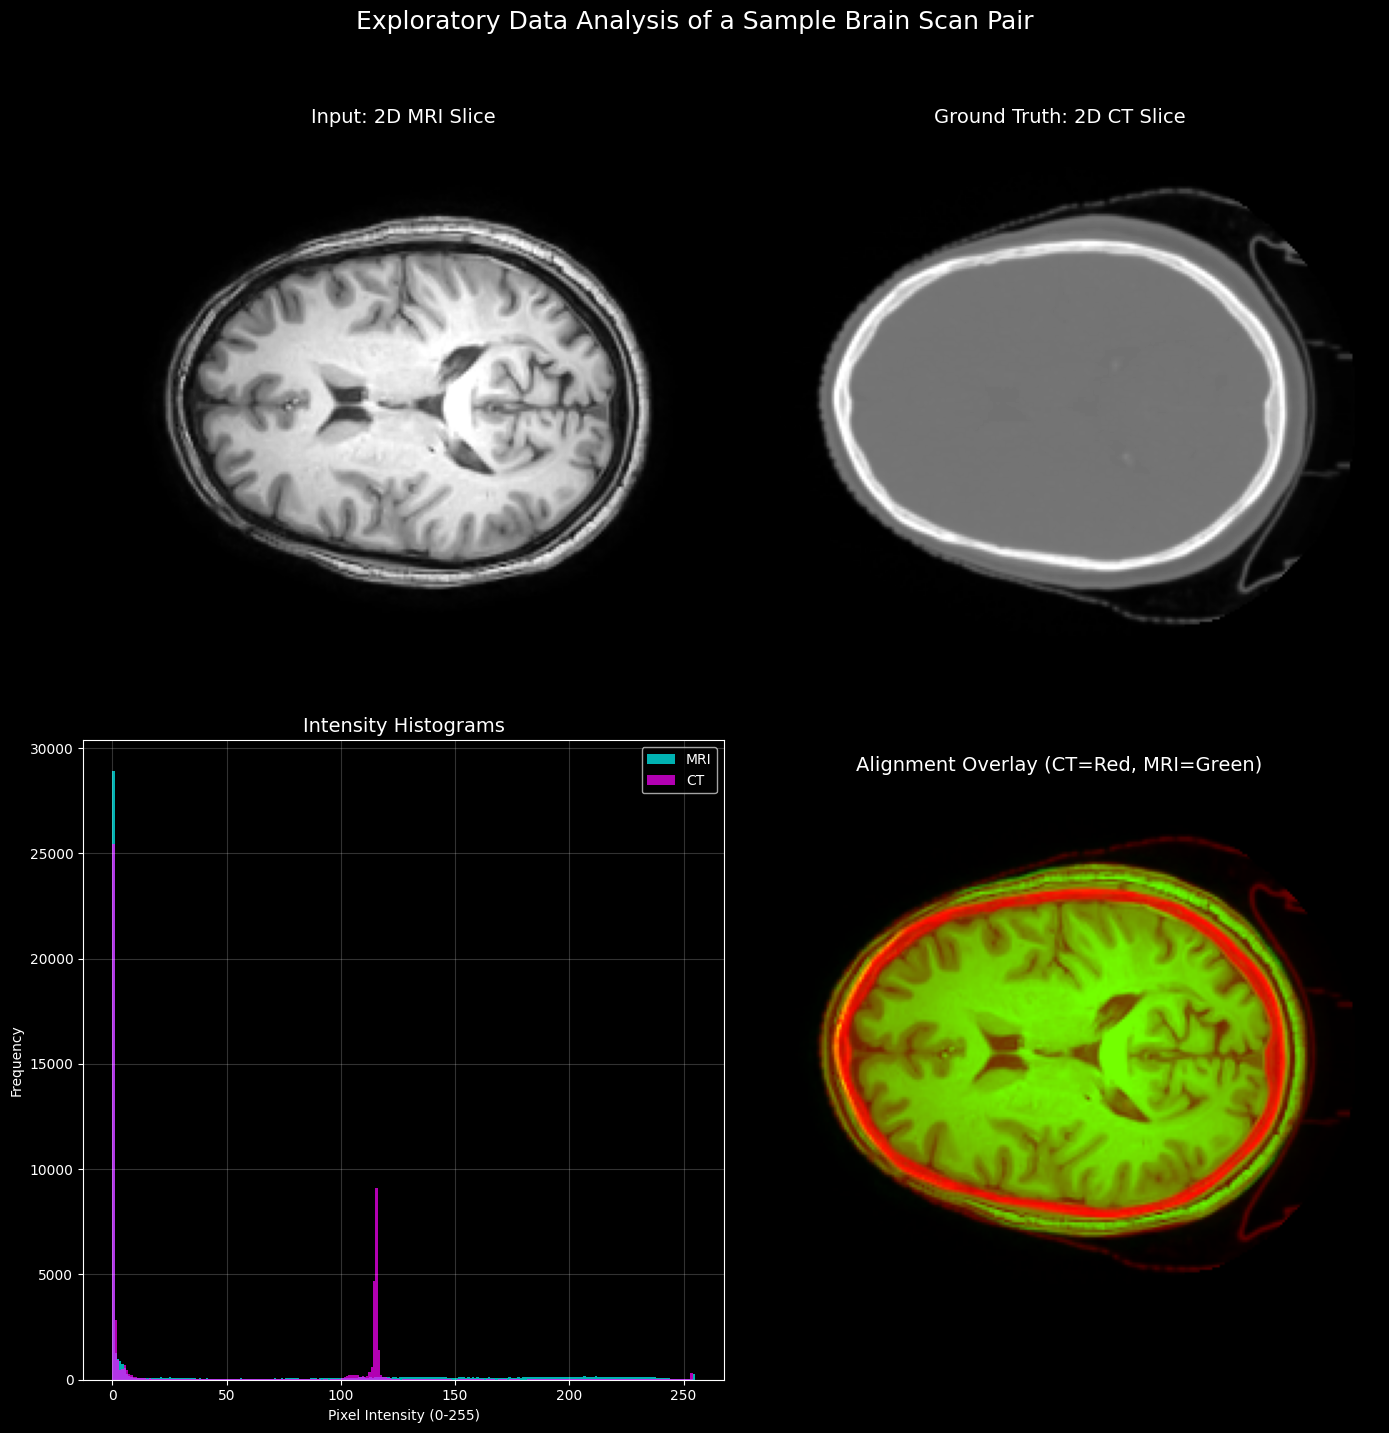

In [3]:
# =============== EXPLORATORY DATA ANALYSIS ===================== 
"""
This script performs Exploratory Data Analysis (EDA) on the 2D brain slices
prepared in the previous step.
"""

import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import random
import os

# --- 1. Configuration ---
SLICES_PATH = Path('/kaggle/working/processed_2D_BRAIN_slices')  # Confirm this matches where your slices are saved
MRI_SLICES_PATH = SLICES_PATH / 'trainA'
CT_SLICES_PATH = SLICES_PATH / 'trainB'

# --- 2. Pre-run Check ---
if not MRI_SLICES_PATH.exists() or not os.listdir(MRI_SLICES_PATH):
    print(f"❌ ERROR: The directory '{MRI_SLICES_PATH}' is empty or does not exist.")
    print("Please ensure the slicing script (02_enhanced_brain_slicing_kaggle.py) ran successfully.")
else:
    print("✅ Brain-only dataset found. Starting EDA...")

    # --- 3. Load a Random Sample Pair ---
    all_mri_files = list(MRI_SLICES_PATH.glob('*.png'))
    random_mri_path = random.choice(all_mri_files)
    random_ct_path = CT_SLICES_PATH / random_mri_path.name

    print(f"Analyzing sample pair: {random_mri_path.name}")

    # Load images in grayscale
    mri_slice = cv2.imread(str(random_mri_path), cv2.IMREAD_GRAYSCALE)
    ct_slice = cv2.imread(str(random_ct_path), cv2.IMREAD_GRAYSCALE)

    # --- 4. Perform and Visualize the EDA ---
    plt.style.use('dark_background')
    fig, axes = plt.subplots(2, 2, figsize=(14, 14))
    fig.suptitle('Exploratory Data Analysis of a Sample Brain Scan Pair', fontsize=18, y=1.02)

    # a) MRI Slice
    axes[0, 0].imshow(mri_slice, cmap='gray')
    axes[0, 0].set_title('Input: 2D MRI Slice', fontsize=14)
    axes[0, 0].axis('off')

    # b) CT Slice
    axes[0, 1].imshow(ct_slice, cmap='gray')
    axes[0, 1].set_title('Ground Truth: 2D CT Slice', fontsize=14)
    axes[0, 1].axis('off')

    # c) Intensity Histograms
    axes[1, 0].hist(mri_slice.ravel(), bins=256, color='cyan', alpha=0.7, label='MRI')
    axes[1, 0].hist(ct_slice.ravel(), bins=256, color='magenta', alpha=0.7, label='CT')
    axes[1, 0].set_title('Intensity Histograms', fontsize=14)
    axes[1, 0].set_xlabel('Pixel Intensity (0-255)')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].legend()
    axes[1, 0].grid(alpha=0.2)

    # d) Overlay (CT=Red, MRI=Green)
    overlay_img = np.zeros((*mri_slice.shape, 3), dtype=np.uint8)
    overlay_img[..., 0] = ct_slice  # Red channel for CT
    overlay_img[..., 1] = mri_slice # Green channel for MRI

    axes[1, 1].imshow(overlay_img)
    axes[1, 1].set_title('Alignment Overlay (CT=Red, MRI=Green)', fontsize=14)
    axes[1, 1].axis('off')

    plt.tight_layout()
    plt.show()


In [4]:
#                                  ==================== MODEL DEFINITION ======================
import torch
import torch.nn as nn
import torch.nn.functional as F

# -------- Turbo-U-Net blocks ----------
class ResidualBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv1 = nn.Conv2d(in_c, out_c, 3, padding=1)
        self.bn1   = nn.BatchNorm2d(out_c)
        self.conv2 = nn.Conv2d(out_c, out_c, 3, padding=1)
        self.bn2   = nn.BatchNorm2d(out_c)
        self.skip  = nn.Conv2d(in_c, out_c, 1) if in_c != out_c else None

    def forward(self, x):
        identity = x if self.skip is None else self.skip(x)
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return F.relu(out + identity)

def up_block(in_c, out_c):
    return nn.Sequential(
        nn.ConvTranspose2d(in_c, out_c, 2, stride=2),
        nn.BatchNorm2d(out_c),
        nn.ReLU(inplace=True)
    )

class TurboUNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, base=32):
        super().__init__()
        # Encoder
        self.enc1 = ResidualBlock(in_channels, base)
        self.enc2 = ResidualBlock(base, base*2)
        self.enc3 = ResidualBlock(base*2, base*4)
        self.enc4 = ResidualBlock(base*4, base*8)
        self.pool = nn.MaxPool2d(2)
        # Bottleneck
        self.bottleneck = ResidualBlock(base*8, base*16)
        # Decoder
        self.up4 = up_block(base*16, base*8)
        self.dec4 = ResidualBlock(base*16, base*8)
        self.up3 = up_block(base*8, base*4)
        self.dec3 = ResidualBlock(base*8, base*4)
        self.up2 = up_block(base*4, base*2)
        self.dec2 = ResidualBlock(base*4, base*2)
        self.up1 = up_block(base*2, base)
        self.dec1 = ResidualBlock(base*2, base)
        self.final = nn.Conv2d(base, out_channels, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b  = self.bottleneck(self.pool(e4))

        d4 = self.up4(b); d4 = self.dec4(torch.cat([d4, e4], 1))
        d3 = self.up3(d4); d3 = self.dec3(torch.cat([d3, e3], 1))
        d2 = self.up2(d3); d2 = self.dec2(torch.cat([d2, e2], 1))
        d1 = self.up1(d2); d1 = self.dec1(torch.cat([d1, e1], 1))
        return torch.sigmoid(self.final(d1))   # output in [0,1]


In [6]:
import torch
import torch.nn as nn

class PatchDiscriminator(nn.Module):
    def __init__(self, in_channels=2, base=32):
        # in_channels = input + generated (concatenated)
        super().__init__()
        def block(in_c, out_c, norm=True):
            layers = [nn.Conv2d(in_c, out_c, 4, stride=2, padding=1)]
            if norm: layers.append(nn.BatchNorm2d(out_c))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return nn.Sequential(*layers)

        self.model = nn.Sequential(
            block(in_channels, base, norm=False),
            block(base, base*2),
            block(base*2, base*4),
            block(base*4, base*8),
            nn.Conv2d(base*8, 1, 4, padding=1)  # Patch map
        )

    def forward(self, x, y):
        # x: input image, y: real or fake output
        return self.model(torch.cat([x, y], dim=1))


In [7]:
import torch
import torch.nn as nn
from torchmetrics import StructuralSimilarityIndexMeasure, MultiScaleStructuralSimilarityIndexMeasure

class CombinedLoss(nn.Module):
    """
    Combined loss for U-Net / Pix2Pix:
    L = L1 + SSIM + MS-SSIM + optional adversarial
    ✅ No spatial MSE, works with torchmetrics
    """
    def __init__(self, l1_weight=0.5, ssim_weight=0.3, ms_ssim_weight=0.2, adv_weight=0.0):
        super().__init__()
        self.l1_weight = l1_weight
        self.ssim_weight = ssim_weight
        self.ms_ssim_weight = ms_ssim_weight
        self.adv_weight = adv_weight

        self.l1_loss_fn = nn.L1Loss()
        self.ssim_fn = StructuralSimilarityIndexMeasure(data_range=1.0)
        self.ms_ssim_fn = MultiScaleStructuralSimilarityIndexMeasure(data_range=1.0)

    def forward(self, pred, target, adv_pred=None):
        # ---------- L1 Loss ----------
        l1_loss = self.l1_loss_fn(pred, target)

        # ---------- SSIM Loss ----------
        ssim_loss = self.ssim_fn(pred, target)

        # ---------- MS-SSIM Loss ----------
        ms_ssim_loss = self.ms_ssim_fn(pred, target)

        # ---------- Adversarial Loss ----------
        adv_loss = 0.1
        if adv_pred is not None and self.adv_weight > 0.0:
            adv_loss = torch.mean((adv_pred - 1.0) ** 2)  # LSGAN style

        # ---------- Total Loss ----------
        total_loss = (
            self.l1_weight * l1_loss +
            self.ssim_weight * ssim_loss +
            self.ms_ssim_weight * ms_ssim_loss +
            self.adv_weight * adv_loss
        )

        return total_loss, l1_loss, ssim_loss, ms_ssim_loss, adv_loss

# --- HU Denormalization Helper ---
def denormalize_to_hu(tensor, min_val=-1000, max_val=2000):
    """
    Inverse of min-max normalization to [0,1].
    If your pipeline uses [-1,1] normalization, adjust accordingly.

    """
    return tensor * (max_val - min_val) + min_val

print("✅ Kaggle-ready model & loss function defined.")


✅ Kaggle-ready model & loss function defined.


In [8]:
# ====================== FIXED DATA LOADING & TRAINING SETUP ==========================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
from PIL import Image
from pathlib import Path
import random
import os

# ====================== CONFIG ======================
# Paths
DATASET_PATH = Path('/kaggle/working/processed_2D_BRAIN_slices')
BEST_MODEL_PATH = Path('/kaggle/working/best_mri_to_ct_turbo_unet.pth')
CHECKPOINT_DIR = Path('/kaggle/working/checkpoints_turbo_unet')
CHECKPOINT_DIR.mkdir(exist_ok=True)

# Training Hyperparameters
NUM_EPOCHS = 20
LEARNING_RATE = 2e-4
BATCH_SIZE = 8

# Device configuration
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")


# ====================== DATASET CLASS ======================
class MRItoCTDataset(Dataset):
    """Custom PyTorch Dataset for paired MRI and CT images."""
    def __init__(self, root_dir, transform=None):
        self.root_dir = Path(root_dir)
        self.mri_dir = self.root_dir / 'trainA'
        self.ct_dir = self.root_dir / 'trainB'
        self.mri_files = sorted(os.listdir(self.mri_dir))
        self.transform = transform
    
    def __len__(self):
        return len(self.mri_files)
    
    def __getitem__(self, idx):
        mri_path = self.mri_dir / self.mri_files[idx]
        ct_path = self.ct_dir / self.mri_files[idx]
        
        mri_image = Image.open(mri_path).convert("L")
        ct_image = Image.open(ct_path).convert("L")
        
        if self.transform:
            mri_image = self.transform(mri_image)
            ct_image = self.transform(ct_image)
        
        return mri_image, ct_image


# ====================== TRANSFORMS ======================
transform = transforms.Compose([
    transforms.Resize((256, 256), antialias=True),
    transforms.ToTensor()
])

# Load dataset
dataset = MRItoCTDataset(root_dir=DATASET_PATH, transform=transform)
print(f"Total dataset size: {len(dataset)} images")


# ====================== PATIENT-LEVEL SPLIT ======================
def create_patient_level_split(dataset, val_fraction=0.15, test_fraction=0.15):
    """Create train, val, and test subsets ensuring NO patient overlap"""
    
    # Extract unique patient IDs from dataset filenames
    all_files = dataset.mri_files
    patient_ids = list(set([f.split('_')[0] for f in all_files]))
    print(f"Total unique patients: {len(patient_ids)}")
    
    # Shuffle patients
    random.seed(42)
    random.shuffle(patient_ids)
    
    # Compute split sizes
    n_total = len(patient_ids)
    n_test = int(n_total * test_fraction)
    n_val = int(n_total * val_fraction)
    
    test_patient_ids = set(patient_ids[:n_test])
    val_patient_ids = set(patient_ids[n_test:n_test + n_val])
    train_patient_ids = set(patient_ids[n_test + n_val:])
    
    # Map slices to splits
    train_indices, val_indices, test_indices = [], [], []
    for idx, fname in enumerate(all_files):
        patient_id = fname.split('_')[0]
        if patient_id in train_patient_ids:
            train_indices.append(idx)
        elif patient_id in val_patient_ids:
            val_indices.append(idx)
        elif patient_id in test_patient_ids:
            test_indices.append(idx)
    
    # Create subsets
    train_subset = Subset(dataset, train_indices)
    val_subset = Subset(dataset, val_indices)
    test_subset = Subset(dataset, test_indices)
    
    # Verify no leakage
    overlap = train_patient_ids & val_patient_ids | val_patient_ids & test_patient_ids | train_patient_ids & test_patient_ids
    print(f"✅ PROPER SPLIT RESULTS:")
    print(f"   Train patients: {len(train_patient_ids)} | slices: {len(train_subset)}")
    print(f"   Val patients:   {len(val_patient_ids)} | slices: {len(val_subset)}")
    print(f"   Test patients:  {len(test_patient_ids)} | slices: {len(test_subset)}")
    print(f"   Patient overlap: {len(overlap)} (MUST be 0)")
    
    if len(overlap) == 0:
        print("✅ SUCCESS: No patient data leakage!")
    else:
        print("❌ ERROR: Patient overlap detected!")
    
    return train_subset, val_subset, test_subset


# Create proper split
train_dataset, val_dataset, test_dataset = create_patient_level_split(
    dataset, val_fraction=0.15, test_fraction=0.15
)

# ====================== DATALOADERS ======================
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)


# ====================== MODEL & OPTIMIZER ======================

# Generator and Discriminator
generator = TurboUNet(in_channels=1, out_channels=1).to(device)
torch.cuda.empty_cache()
discriminator = PatchDiscriminator(in_channels=2).to(device)   # input + output concatenated

# Losses
gen_loss_fn = CombinedLoss(l1_weight=0.5, ssim_weight=0.3, ms_ssim_weight=0.2, adv_weight=1.0).to(device)
adv_criterion = nn.MSELoss()  # for discriminator (LSGAN)

# Optimizers
g_optimizer = optim.Adam(generator.parameters(), lr=LEARNING_RATE, betas=(0.5, 0.999))
d_optimizer = optim.Adam(discriminator.parameters(), lr=LEARNING_RATE, betas=(0.5, 0.999))

# Optional LR scheduler for generator
g_scheduler = optim.lr_scheduler.ReduceLROnPlateau(g_optimizer, mode='min', patience=3, factor=0.5)


print("✅ FIXED Training setup complete!")
print(f"Generator params:     {sum(p.numel() for p in generator.parameters()):,}")
print(f"Discriminator params: {sum(p.numel() for p in discriminator.parameters()):,}")



Using device: cuda
Total dataset size: 17669 images
Total unique patients: 180
✅ PROPER SPLIT RESULTS:
   Train patients: 126 | slices: 12384
   Val patients:   27 | slices: 2614
   Test patients:  27 | slices: 2671
   Patient overlap: 0 (MUST be 0)
✅ SUCCESS: No patient data leakage!
✅ FIXED Training setup complete!
Generator params:     8,116,033
Discriminator params: 694,625


/usr/local/lib/python3.11/dist-packages/torchmetrics/utilities/prints.py:62: FutureWarning: Importing `StructuralSimilarityIndexMeasure` from `torchmetrics` was deprecated and will be removed in 2.0. Import `StructuralSimilarityIndexMeasure` from `torchmetrics.image` instead.
  _future_warning(
/usr/local/lib/python3.11/dist-packages/torchmetrics/utilities/prints.py:62: FutureWarning: Importing `MultiScaleStructuralSimilarityIndexMeasure` from `torchmetrics` was deprecated and will be removed in 2.0. Import `MultiScaleStructuralSimilarityIndexMeasure` from `torchmetrics.image` instead.
  _future_warning(



🚀 Starting TURBO U-Net + Pix2Pix Training 


Validation: 100%|██████████| 327/327 [00:14<00:00, 21.91it/s, val_loss=0.4236, val_ssim=0.4958]


   🌟 NEW BEST MODEL! Validation SSIM: 0.464046

📊 Epoch 1 Summary:
   • Train Loss: 0.629524 | Val Loss: 0.401870
   • Train SSIM: 0.370141 | Val SSIM: 0.464046
   • Train MAE (HU): 236.11 | Val MAE (HU): 183.06


Validation: 100%|██████████| 327/327 [00:13<00:00, 23.38it/s, val_loss=0.4903, val_ssim=0.6849]


   🌟 NEW BEST MODEL! Validation SSIM: 0.586876

📊 Epoch 2 Summary:
   • Train Loss: 0.675122 | Val Loss: 0.449396
   • Train SSIM: 0.533161 | Val SSIM: 0.586876
   • Train MAE (HU): 170.44 | Val MAE (HU): 155.80


Validation: 100%|██████████| 327/327 [00:13<00:00, 23.42it/s, val_loss=0.4794, val_ssim=0.6499]


   🌟 NEW BEST MODEL! Validation SSIM: 0.596894

📊 Epoch 3 Summary:
   • Train Loss: 0.696669 | Val Loss: 0.453478
   • Train SSIM: 0.604517 | Val SSIM: 0.596894
   • Train MAE (HU): 151.36 | Val MAE (HU): 164.17


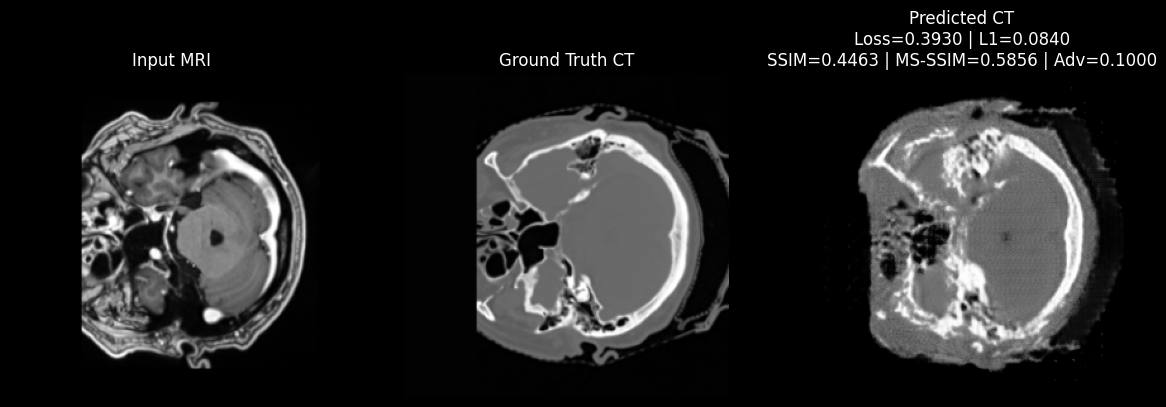

   💾 Checkpoint saved: checkpoint_epoch_3.pth


Validation: 100%|██████████| 327/327 [00:13<00:00, 23.42it/s, val_loss=0.4977, val_ssim=0.6877]


   🌟 NEW BEST MODEL! Validation SSIM: 0.660284

📊 Epoch 4 Summary:
   • Train Loss: 0.712760 | Val Loss: 0.478112
   • Train SSIM: 0.650463 | Val SSIM: 0.660284
   • Train MAE (HU): 139.55 | Val MAE (HU): 147.26


Validation: 100%|██████████| 327/327 [00:13<00:00, 23.42it/s, val_loss=0.5569, val_ssim=0.8548]


   🌟 NEW BEST MODEL! Validation SSIM: 0.715305

📊 Epoch 5 Summary:
   • Train Loss: 0.723896 | Val Loss: 0.497068
   • Train SSIM: 0.682423 | Val SSIM: 0.715305
   • Train MAE (HU): 130.27 | Val MAE (HU): 124.19


Validation: 100%|██████████| 327/327 [00:14<00:00, 23.23it/s, val_loss=0.5367, val_ssim=0.7973]


   🌟 NEW BEST MODEL! Validation SSIM: 0.717327

📊 Epoch 6 Summary:
   • Train Loss: 0.730549 | Val Loss: 0.498112
   • Train SSIM: 0.701129 | Val SSIM: 0.717327
   • Train MAE (HU): 124.86 | Val MAE (HU): 119.49


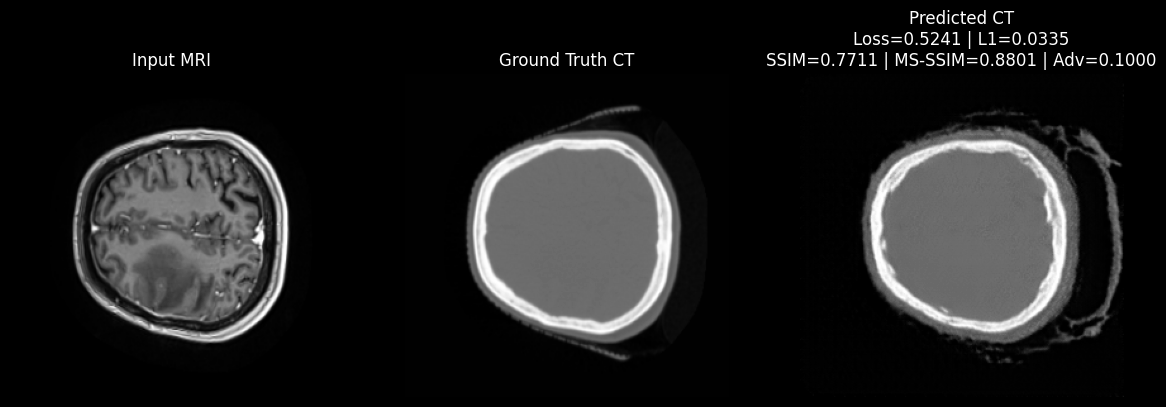

   💾 Checkpoint saved: checkpoint_epoch_6.pth


Validation: 100%|██████████| 327/327 [00:13<00:00, 23.43it/s, val_loss=0.5596, val_ssim=0.8644]


   🌟 NEW BEST MODEL! Validation SSIM: 0.720201

📊 Epoch 7 Summary:
   • Train Loss: 0.743222 | Val Loss: 0.500178
   • Train SSIM: 0.723698 | Val SSIM: 0.720201
   • Train MAE (HU): 119.03 | Val MAE (HU): 118.10


Validation: 100%|██████████| 327/327 [00:13<00:00, 23.38it/s, val_loss=0.5617, val_ssim=0.8719]


   🌟 NEW BEST MODEL! Validation SSIM: 0.766772

📊 Epoch 8 Summary:
   • Train Loss: 0.752331 | Val Loss: 0.516701
   • Train SSIM: 0.751217 | Val SSIM: 0.766772
   • Train MAE (HU): 112.31 | Val MAE (HU): 106.42


Validation: 100%|██████████| 327/327 [00:14<00:00, 23.35it/s, val_loss=0.5525, val_ssim=0.8354]



📊 Epoch 9 Summary:
   • Train Loss: 0.757838 | Val Loss: 0.511749
   • Train SSIM: 0.769201 | Val SSIM: 0.749984
   • Train MAE (HU): 107.91 | Val MAE (HU): 110.41


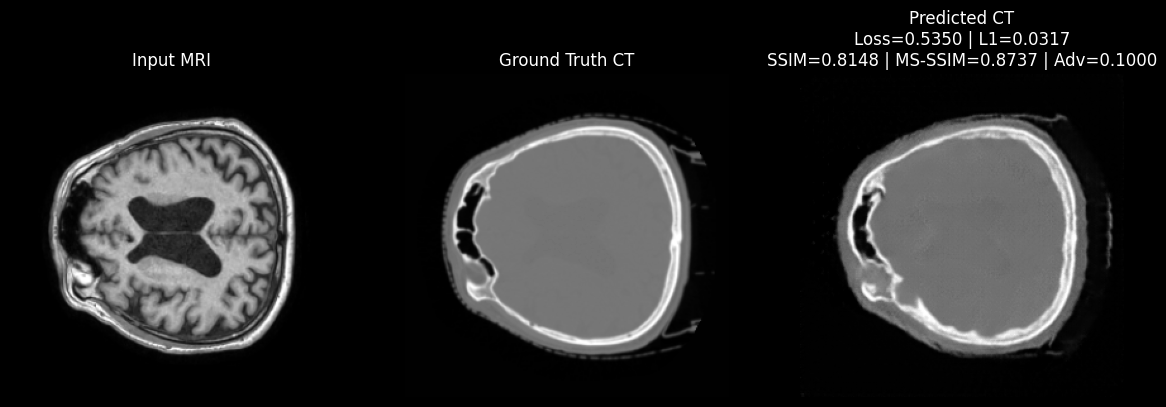

   💾 Checkpoint saved: checkpoint_epoch_9.pth


Validation: 100%|██████████| 327/327 [00:14<00:00, 23.34it/s, val_loss=0.5565, val_ssim=0.8598]


   🌟 NEW BEST MODEL! Validation SSIM: 0.768118

📊 Epoch 10 Summary:
   • Train Loss: 0.764549 | Val Loss: 0.518808
   • Train SSIM: 0.781885 | Val SSIM: 0.768118
   • Train MAE (HU): 102.94 | Val MAE (HU): 104.34


Validation: 100%|██████████| 327/327 [00:13<00:00, 23.40it/s, val_loss=0.5679, val_ssim=0.8746]


   🌟 NEW BEST MODEL! Validation SSIM: 0.776439

📊 Epoch 11 Summary:
   • Train Loss: 0.775245 | Val Loss: 0.521823
   • Train SSIM: 0.788412 | Val SSIM: 0.776439
   • Train MAE (HU): 100.67 | Val MAE (HU): 105.33


Validation: 100%|██████████| 327/327 [00:13<00:00, 23.41it/s, val_loss=0.5668, val_ssim=0.8803]


   🌟 NEW BEST MODEL! Validation SSIM: 0.792421

📊 Epoch 12 Summary:
   • Train Loss: 0.786264 | Val Loss: 0.527743
   • Train SSIM: 0.795506 | Val SSIM: 0.792421
   • Train MAE (HU): 97.71 | Val MAE (HU): 98.55


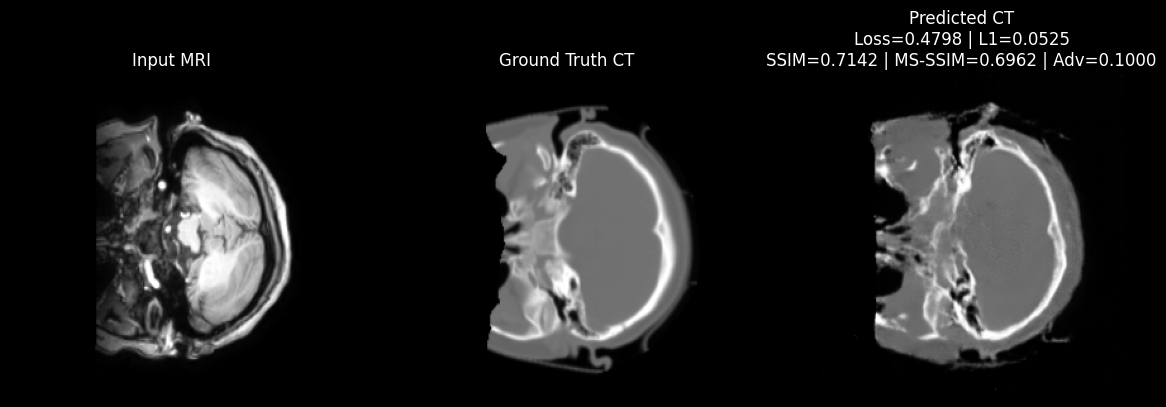

   💾 Checkpoint saved: checkpoint_epoch_12.pth


Validation: 100%|██████████| 327/327 [00:13<00:00, 23.44it/s, val_loss=0.5688, val_ssim=0.8788]



📊 Epoch 13 Summary:
   • Train Loss: 0.797162 | Val Loss: 0.525301
   • Train SSIM: 0.801963 | Val SSIM: 0.785726
   • Train MAE (HU): 95.13 | Val MAE (HU): 104.86


Validation: 100%|██████████| 327/327 [00:13<00:00, 23.41it/s, val_loss=0.5647, val_ssim=0.8688]



📊 Epoch 14 Summary:
   • Train Loss: 0.809078 | Val Loss: 0.527383
   • Train SSIM: 0.809554 | Val SSIM: 0.789880
   • Train MAE (HU): 91.92 | Val MAE (HU): 101.31


Validation: 100%|██████████| 327/327 [00:13<00:00, 23.42it/s, val_loss=0.5686, val_ssim=0.8890]


   🌟 NEW BEST MODEL! Validation SSIM: 0.802899

📊 Epoch 15 Summary:
   • Train Loss: 0.827602 | Val Loss: 0.531976
   • Train SSIM: 0.812859 | Val SSIM: 0.802899
   • Train MAE (HU): 90.38 | Val MAE (HU): 94.55


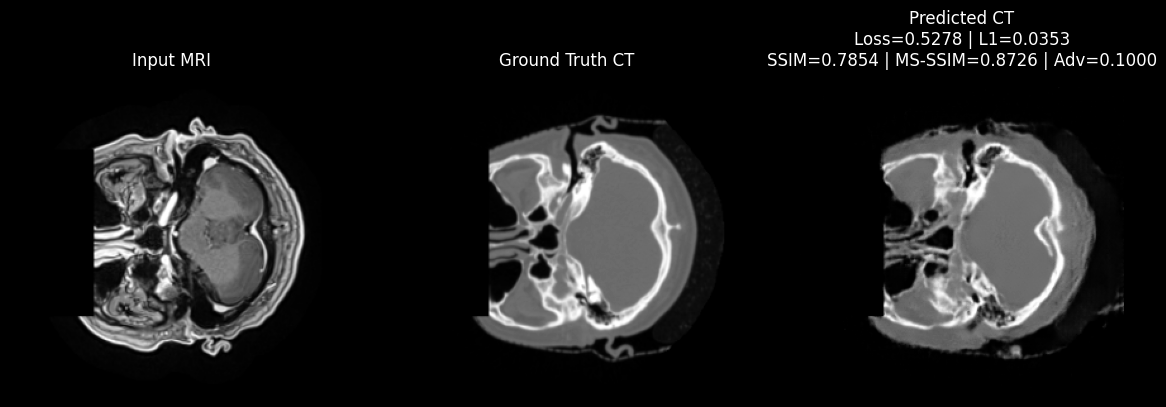

   💾 Checkpoint saved: checkpoint_epoch_15.pth


Validation: 100%|██████████| 327/327 [00:13<00:00, 23.39it/s, val_loss=0.5633, val_ssim=0.8729]



📊 Epoch 16 Summary:
   • Train Loss: 0.844521 | Val Loss: 0.531545
   • Train SSIM: 0.815424 | Val SSIM: 0.801736
   • Train MAE (HU): 89.41 | Val MAE (HU): 95.07


Validation: 100%|██████████| 327/327 [00:13<00:00, 23.59it/s, val_loss=0.5643, val_ssim=0.8752]



📊 Epoch 17 Summary:
   • Train Loss: 0.859956 | Val Loss: 0.530952
   • Train SSIM: 0.818027 | Val SSIM: 0.798637
   • Train MAE (HU): 88.51 | Val MAE (HU): 96.32


Validation: 100%|██████████| 327/327 [00:13<00:00, 23.46it/s, val_loss=0.5646, val_ssim=0.8743]


   🌟 NEW BEST MODEL! Validation SSIM: 0.805815

📊 Epoch 18 Summary:
   • Train Loss: 0.878287 | Val Loss: 0.533302
   • Train SSIM: 0.822352 | Val SSIM: 0.805815
   • Train MAE (HU): 86.68 | Val MAE (HU): 92.29


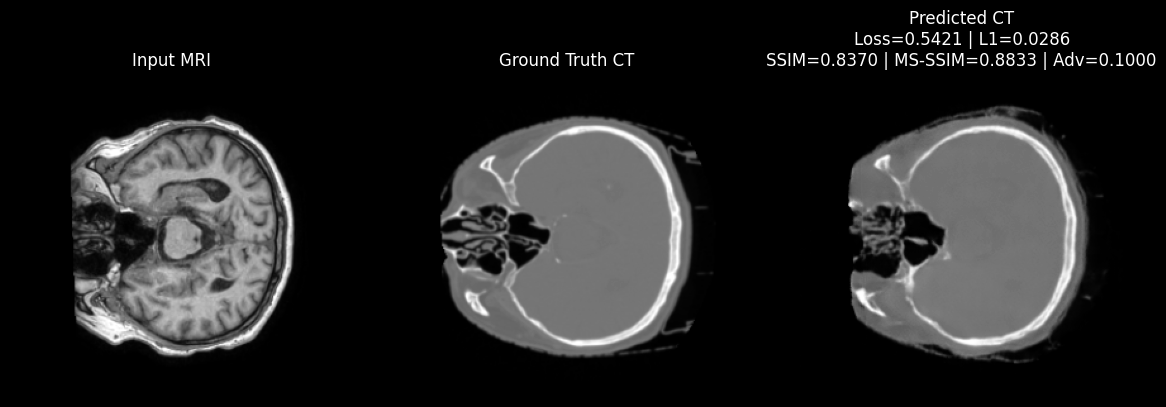

   💾 Checkpoint saved: checkpoint_epoch_18.pth


Validation: 100%|██████████| 327/327 [00:13<00:00, 23.53it/s, val_loss=0.5666, val_ssim=0.8839]



📊 Epoch 19 Summary:
   • Train Loss: 0.900211 | Val Loss: 0.533051
   • Train SSIM: 0.823639 | Val SSIM: 0.805473
   • Train MAE (HU): 86.22 | Val MAE (HU): 92.90


Validation: 100%|██████████| 327/327 [00:13<00:00, 23.56it/s, val_loss=0.5642, val_ssim=0.8772]



📊 Epoch 20 Summary:
   • Train Loss: 0.918913 | Val Loss: 0.532887
   • Train SSIM: 0.825054 | Val SSIM: 0.804925
   • Train MAE (HU): 85.73 | Val MAE (HU): 93.22

🎉 Training Complete!
✅ Final model saved to: /kaggle/working/final_mri_to_ct_turbo_unet.pth
🌟 Best model saved to: /kaggle/working/best_mri_to_ct_turbo_unet.pth


In [9]:
import random
from tqdm import tqdm
import matplotlib.pyplot as plt
import torch
from pathlib import Path
import numpy as np

# --- Fixed Visualization Function ---
import matplotlib.pyplot as plt
import random
import torch

def visualize_progress(model, val_dataset, device, epoch, loss_fn, num_samples=3):
    """Visualize random predictions vs. ground truth CT with metrics."""
    model.eval()
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4 * num_samples))

    if num_samples == 1:
        axes = [axes]  # ensure iterable when only 1 sample

    for i in range(num_samples):
        idx = random.randint(0, len(val_dataset) - 1)
        mri, ct = val_dataset[idx]
        mri, ct = mri.unsqueeze(0).to(device), ct.unsqueeze(0).to(device)

        with torch.no_grad():
            pred = model(mri)
            loss, l1_val, ssim_val, ms_ssim_val, adv_val = loss_fn(pred, ct)

        # Safely convert to float (whether tensor or already float)
        def to_float(x):
            return x.item() if hasattr(x, "item") else float(x)

        loss, l1_val, ssim_val, ms_ssim_val, adv_val = map(to_float, 
            [loss, l1_val, ssim_val, ms_ssim_val, adv_val])

        mri_np  = mri.squeeze().cpu().numpy()
        ct_np   = ct.squeeze().cpu().numpy()
        pred_np = pred.squeeze().cpu().numpy()

        # Plot
        axes[i][0].imshow(mri_np, cmap="gray")
        axes[i][0].set_title("Input MRI")
        axes[i][0].axis("off")

        axes[i][1].imshow(ct_np, cmap="gray")
        axes[i][1].set_title("Ground Truth CT")
        axes[i][1].axis("off")

        axes[i][2].imshow(pred_np, cmap="gray")
        axes[i][2].set_title(
            f"Predicted CT\n"
            f"Loss={loss:.4f} | L1={l1_val:.4f}\n"
            f"SSIM={ssim_val:.4f} | MS-SSIM={ms_ssim_val:.4f} | Adv={adv_val:.4f}"
        )
        axes[i][2].axis("off")

    plt.tight_layout()
    plt.show()


print("\n" + "="*70)
print("🚀 Starting TURBO U-Net + Pix2Pix Training ")
print("="*70)

# Training metrics tracking
train_losses, train_l1_losses, train_ssim_scores = [], [], []
train_mae_hu_scores, train_mse_scores = [], []
val_losses, val_l1_losses, val_ssim_scores = [], [], []
val_mae_hu_scores, val_mse_scores = [], []

best_val_ssim = 0.0
best_epoch = 0
patience = 7
early_stop_counter = 0

history = {
    "train_loss": [], "val_loss": [],
    "train_l1": [],  "val_l1": [],
    "train_ssim": [],"val_ssim": [],
    "train_mae_hu": [], "val_mae_hu": [],
}
combined_loss_fn = gen_loss_fn


for epoch in range(NUM_EPOCHS):
    # =================== TRAINING ===================
    generator.train()
    discriminator.train()

    epoch_loss = epoch_l1 = epoch_ssim = 0.0
    epoch_mae_hu = d_epoch_loss = g_epoch_loss = 0.0

    loop = tqdm(train_loader, leave=True)
    loop.set_description(f"Epoch [{epoch+1}/{NUM_EPOCHS}] Training")

    for mri, ct in loop:
        mri, ct = mri.to(device), ct.to(device)

        # ------------------------------------------------
        # 1️⃣  Train Discriminator
        # ------------------------------------------------
        d_optimizer.zero_grad()
        with torch.no_grad():
            fake_ct = generator(mri)

        d_real = discriminator(mri, ct)
        d_fake = discriminator(mri, fake_ct)

        real_targets = torch.ones_like(d_real) * 0.9
        fake_targets = torch.zeros_like(d_fake)

        d_loss = 0.5 * (adv_criterion(d_real, real_targets) + adv_criterion(d_fake, fake_targets))
        d_loss.backward()
        torch.nn.utils.clip_grad_norm_(discriminator.parameters(), 1.0)
        d_optimizer.step()
        d_epoch_loss += d_loss.item()

        # ------------------------------------------------
        # 2️⃣ Train Generator
        # ------------------------------------------------
        g_optimizer.zero_grad()
        fake_ct = generator(mri)
        d_fake_for_g = discriminator(mri, fake_ct)

        # Combined loss without spatial MSE
        g_loss, l1_val, ssim_val, ms_ssim_val, adv_val = gen_loss_fn(fake_ct, ct, adv_pred=d_fake_for_g)
        g_loss.backward()
        torch.nn.utils.clip_grad_norm_(generator.parameters(), 1.0)
        g_optimizer.step()
        g_epoch_loss += g_loss.item()

        # ---- Metrics ----
        epoch_loss += g_loss.item()
        epoch_l1   += l1_val.item()
        epoch_ssim += ssim_val.item()

        pred_hu = denormalize_to_hu(fake_ct)
        ct_hu   = denormalize_to_hu(ct)
        epoch_mae_hu += torch.mean(torch.abs(pred_hu - ct_hu)).item()

        loop.set_postfix(
            d_loss=f"{d_loss.item():.4f}",
            g_loss=f"{g_loss.item():.4f}",
            l1=f"{l1_val.item():.4f}",
            ssim=f"{ssim_val.item():.4f}"
        )

    avg_train_loss  = epoch_loss / len(train_loader)
    avg_train_l1    = epoch_l1  / len(train_loader)
    avg_train_ssim  = epoch_ssim/ len(train_loader)
    avg_train_mae_hu= epoch_mae_hu / len(train_loader)


    # =================== VALIDATION ===================
    generator.eval()
    val_epoch_loss = val_epoch_l1 = val_epoch_ssim = 0.0
    val_epoch_mae_hu = 0.0

    with torch.no_grad():
        val_loop = tqdm(val_loader, leave=True)
        val_loop.set_description("Validation")
        for mri, ct in val_loop:
            mri, ct = mri.to(device), ct.to(device)
            predicted_ct = generator(mri)
            loss, l1_loss_val, ssim_val, ms_ssim_val, adv_val = combined_loss_fn(predicted_ct, ct)

            val_epoch_loss += loss.item()
            val_epoch_l1   += l1_loss_val.item()
            val_epoch_ssim += ssim_val.item()

            pred_hu = denormalize_to_hu(predicted_ct)
            ct_hu   = denormalize_to_hu(ct)
            val_epoch_mae_hu += torch.mean(torch.abs(pred_hu - ct_hu)).item()

            val_loop.set_postfix(
                val_loss=f"{loss.item():.4f}",
                val_ssim=f"{ssim_val.item():.4f}"
            )

    avg_val_loss   = val_epoch_loss / len(val_loader)
    avg_val_l1     = val_epoch_l1   / len(val_loader)
    avg_val_ssim   = val_epoch_ssim / len(val_loader)
    avg_val_mae_hu = val_epoch_mae_hu / len(val_loader)

    # -------- Save metrics --------
    train_losses.append(avg_train_loss)
    train_l1_losses.append(avg_train_l1)
    train_ssim_scores.append(avg_train_ssim)
    train_mae_hu_scores.append(avg_train_mae_hu)
    
    val_losses.append(avg_val_loss)
    val_l1_losses.append(avg_val_l1)
    val_ssim_scores.append(avg_val_ssim)
    val_mae_hu_scores.append(avg_val_mae_hu)


    g_scheduler.step(avg_val_loss)

    for k,v in {
        "train_loss":avg_train_loss, "val_loss":avg_val_loss,
        "train_l1":avg_train_l1, "val_l1":avg_val_l1,
        "train_ssim":avg_train_ssim, "val_ssim":avg_val_ssim,
        "train_mae_hu":avg_train_mae_hu, "val_mae_hu":avg_val_mae_hu,
    }.items():
        history[k].append(v)

    # -------- Best model check (based on SSIM) --------
    if avg_val_ssim > best_val_ssim:
        best_val_ssim = avg_val_ssim
        best_epoch = epoch + 1
        early_stop_counter = 0
        torch.save({
            'epoch': epoch + 1,
            'generator': generator.state_dict(),
            'discriminator': discriminator.state_dict(),
            'g_optimizer_state_dict': g_optimizer.state_dict(),
            'd_optimizer_state_dict': d_optimizer.state_dict(),
            'val_loss': avg_val_loss,
            'val_ssim': avg_val_ssim
        }, BEST_MODEL_PATH)
        print(f"   🌟 NEW BEST MODEL! Validation SSIM: {avg_val_ssim:.6f}")
    else:
        early_stop_counter += 1
        if early_stop_counter >= patience:
            print(f"\n⏹ Early stopping at epoch {epoch+1}")
            break

    # -------- Epoch summary --------
    print(f"\n📊 Epoch {epoch+1} Summary:")
    print(f"   • Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f}")
    print(f"   • Train SSIM: {avg_train_ssim:.6f} | Val SSIM: {avg_val_ssim:.6f}")
    print(f"   • Train MAE (HU): {avg_train_mae_hu:.2f} | Val MAE (HU): {avg_val_mae_hu:.2f}")

    # Optional visualization + checkpoint
    if (epoch + 1) % 3 == 0:
        visualize_progress(generator, val_dataset, device, epoch, combined_loss_fn, num_samples=1)
        checkpoint_path = CHECKPOINT_DIR / f"checkpoint_epoch_{epoch+1}.pth"
        torch.save({
            'epoch': epoch + 1,
            'generator': generator.state_dict(),
            'discriminator': discriminator.state_dict(),
            'g_optimizer': g_optimizer.state_dict(),
            'd_optimizer': d_optimizer.state_dict(),
            'history': history
        }, checkpoint_path)
        print(f"   💾 Checkpoint saved: {checkpoint_path.name}")

# --- Final save ---
FINAL_MODEL_PATH = Path('/kaggle/working/final_mri_to_ct_turbo_unet.pth')
torch.save({
    'epoch': len(train_losses),
    'generator': generator.state_dict(),
    'discriminator': discriminator.state_dict(),
    'g_optimizer_state_dict': g_optimizer.state_dict(),
    'd_optimizer_state_dict': d_optimizer.state_dict(),
    'history': history
}, FINAL_MODEL_PATH)

print("\n" + "="*70)
print("🎉 Training Complete!")
print("="*70)
print(f"✅ Final model saved to: {FINAL_MODEL_PATH}")
print(f"🌟 Best model saved to: {BEST_MODEL_PATH}")


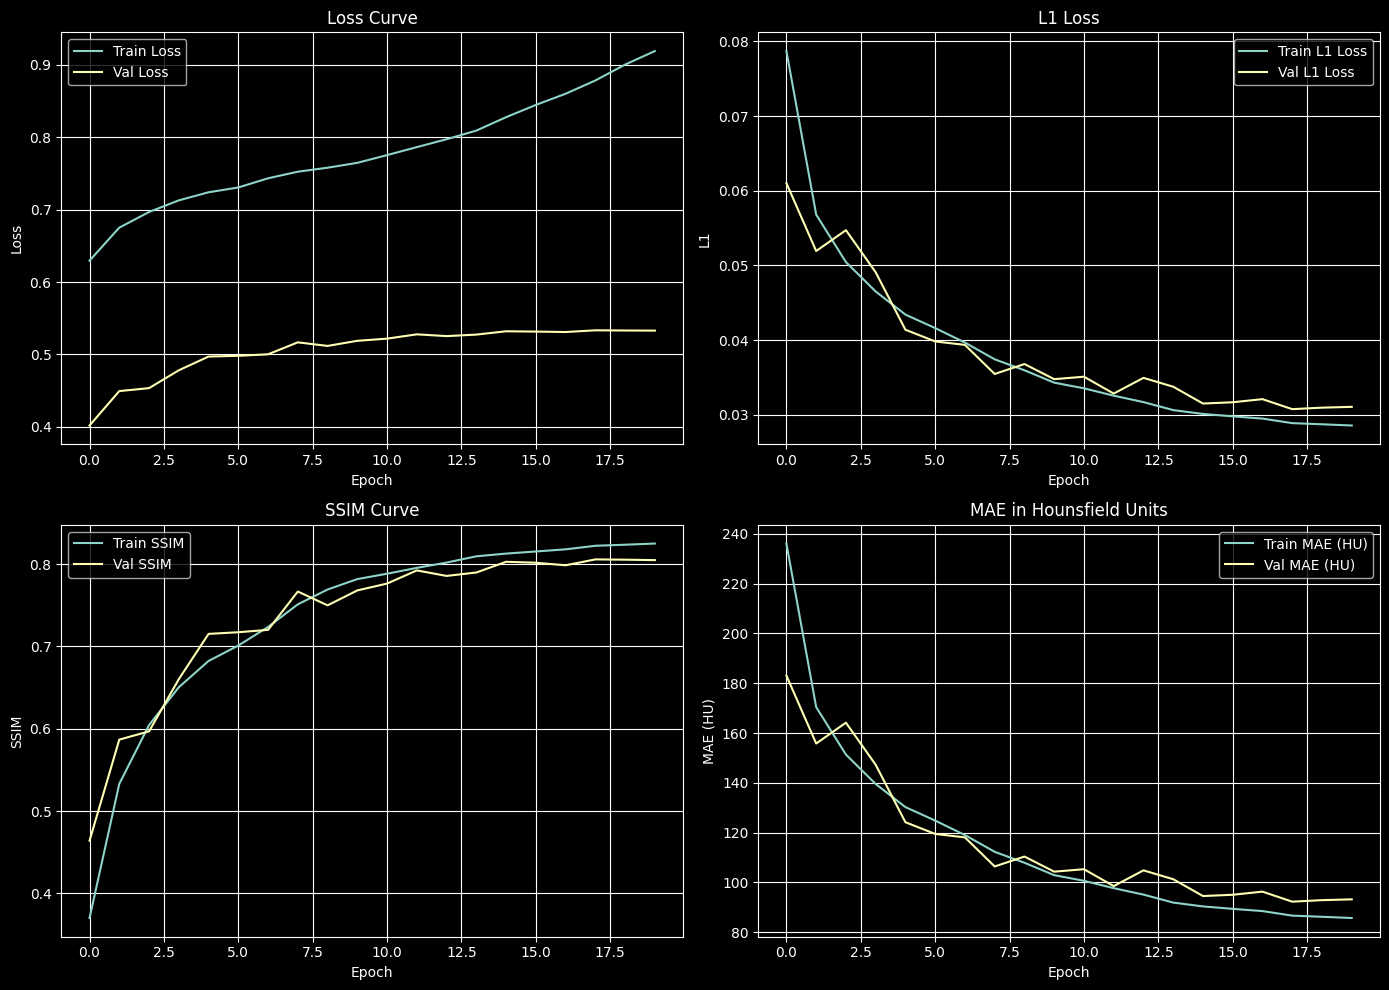

In [12]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    plt.figure(figsize=(14,10))

    # --- Loss ---
    plt.subplot(2,2,1)
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Val Loss")
    plt.title("Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend(); plt.grid(True)

    # --- L1 Loss ---
    plt.subplot(2,2,2)
    plt.plot(history["train_l1"], label="Train L1 Loss")
    plt.plot(history["val_l1"], label="Val L1 Loss")
    plt.title("L1 Loss")
    plt.xlabel("Epoch")
    plt.ylabel("L1")
    plt.legend(); plt.grid(True)

    # --- SSIM ---
    plt.subplot(2,2,3)
    plt.plot(history["train_ssim"], label="Train SSIM")
    plt.plot(history["val_ssim"], label="Val SSIM")
    plt.title("SSIM Curve")
    plt.xlabel("Epoch")
    plt.ylabel("SSIM")
    plt.legend(); plt.grid(True)

    # --- MAE (HU) ---
    plt.subplot(2,2,4)
    plt.plot(history["train_mae_hu"], label="Train MAE (HU)")
    plt.plot(history["val_mae_hu"], label="Val MAE (HU)")
    plt.title("MAE in Hounsfield Units")
    plt.xlabel("Epoch")
    plt.ylabel("MAE (HU)")
    plt.legend(); plt.grid(True)

    plt.tight_layout()
    plt.show()

# Call after training
plot_training_history(history)


In [19]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import random
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
from pathlib import Path

def evaluate_on_test(model, test_loader, device, best_model_path=None, final_model_path=None, num_visuals=3):
    """
    Evaluate trained generator on test set with metrics + visualization.
    Shows random samples instead of first few.
    """

    # --- Load weights ---
    if best_model_path and Path(best_model_path).exists():
        ckpt = torch.load(best_model_path, map_location=device)
        model.load_state_dict(ckpt["generator"])
        print(f"✅ Loaded best model from {best_model_path}")
    elif final_model_path and Path(final_model_path).exists():
        ckpt = torch.load(final_model_path, map_location=device)
        model.load_state_dict(ckpt["generator"])
        print(f"✅ Loaded final model from {final_model_path}")
    else:
        print("⚠️ Warning: No checkpoint found. Using current weights.")

    model.eval()
    test_mae, test_ssim, test_psnr = [], [], []

    all_inputs, all_targets, all_preds = [], [], []

    with torch.no_grad():
        for mri, ct in test_loader:
            mri, ct = mri.to(device), ct.to(device)
            pred = model(mri)

            # --- Denormalize back to HU ---
            pred_hu = denormalize_to_hu(pred.cpu().numpy())
            ct_hu   = denormalize_to_hu(ct.cpu().numpy())

            for i in range(len(mri)):
                gt_img = ct_hu[i,0]
                pred_img = pred_hu[i,0]

                # --- Metrics ---
                test_ssim.append(ssim(gt_img, pred_img, data_range=gt_img.max()-gt_img.min()))
                test_psnr.append(psnr(gt_img, pred_img, data_range=gt_img.max()-gt_img.min()))
                test_mae.append(np.mean(np.abs(gt_img - pred_img)))

                # store ALL samples for random visualization
                all_inputs.append(mri[i,0].cpu().numpy())
                all_targets.append(gt_img)
                all_preds.append(pred_img)

    # --- Final results ---
    results = {
        "SSIM": float(np.mean(test_ssim)),
        "PSNR": float(np.mean(test_psnr)),
        "MAE (HU)": float(np.mean(test_mae)),
    }
    print("\n📊 Test Evaluation Results")
    for k,v in results.items():
        print(f"   • {k}: {v:.4f}")

    # --- Pick random samples ---
    sample_indices = random.sample(range(len(all_inputs)), min(num_visuals, len(all_inputs)))

    # --- Visualization ---
    plt.style.use("dark_background")
    for idx in sample_indices:
        fig, axes = plt.subplots(1,5, figsize=(18,4))
        fig.suptitle(f"Random Test Sample {idx}", fontsize=16, y=1.05)

        inp = all_inputs[idx]
        gt  = all_targets[idx]
        prd = all_preds[idx]

        # MRI input
        axes[0].imshow(inp, cmap="gray")
        axes[0].set_title("MRI Input")
        axes[0].axis("off")

        # Ground Truth CT
        axes[1].imshow(gt, cmap="gray")
        axes[1].set_title("CT Ground Truth")
        axes[1].axis("off")

        # Predicted CT
        axes[2].imshow(prd, cmap="gray")
        axes[2].set_title("CT Predicted")
        axes[2].axis("off")

        # Overlay (GT=Red, Pred=Green)
        overlay = np.zeros((*gt.shape,3), dtype=np.uint8)
        overlay[...,0] = (gt / gt.max() * 255).astype(np.uint8)
        overlay[...,1] = (prd / prd.max() * 255).astype(np.uint8)
        axes[3].imshow(overlay)
        axes[3].set_title("Overlay (GT=R, Pred=G)")
        axes[3].axis("off")

        # Difference heatmap
        diff = np.abs(gt - prd)
        axes[4].imshow(diff, cmap="inferno")
        axes[4].set_title("Abs Error Heatmap")
        axes[4].axis("off")

        plt.tight_layout()
        plt.show()

    # --- Bar chart of metrics ---
    plt.figure(figsize=(6,4))
    plt.bar(results.keys(), results.values(), color=["cyan","magenta","yellow"])
    plt.title("📈 Test Metrics Summary")
    plt.ylabel("Score")
    plt.show()

    return results


✅ Loaded best model from /kaggle/working/best_mri_to_ct_turbo_unet.pth

📊 Test Evaluation Results
   • SSIM: 0.8118
   • PSNR: 22.8752
   • MAE (HU): 95.1258


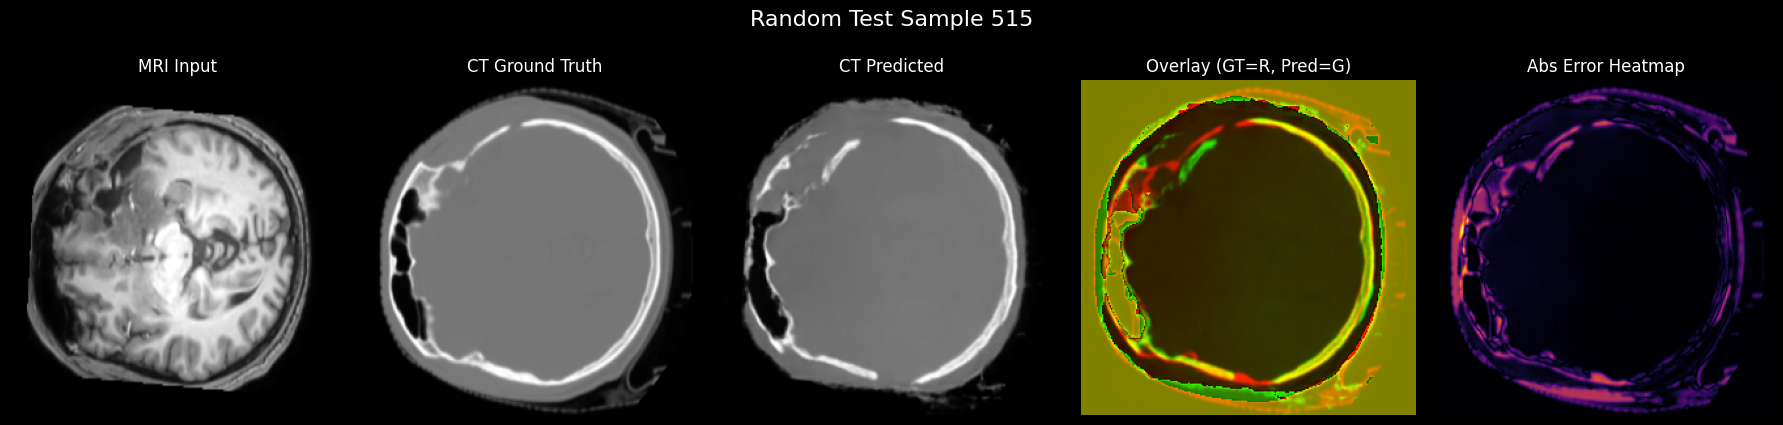

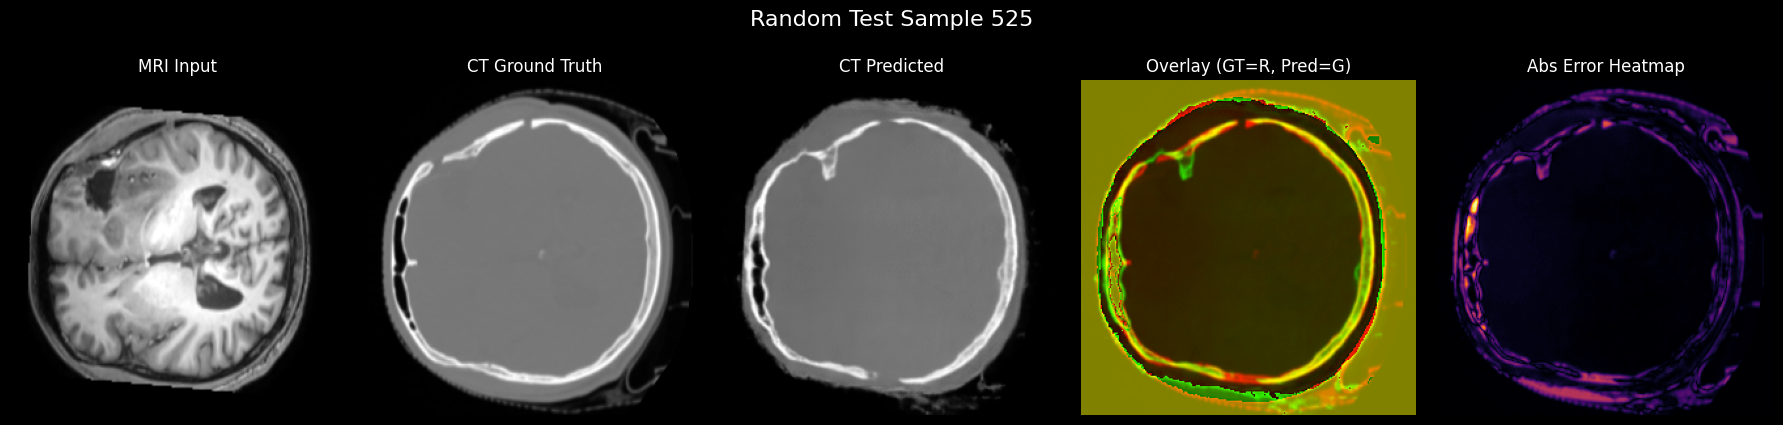

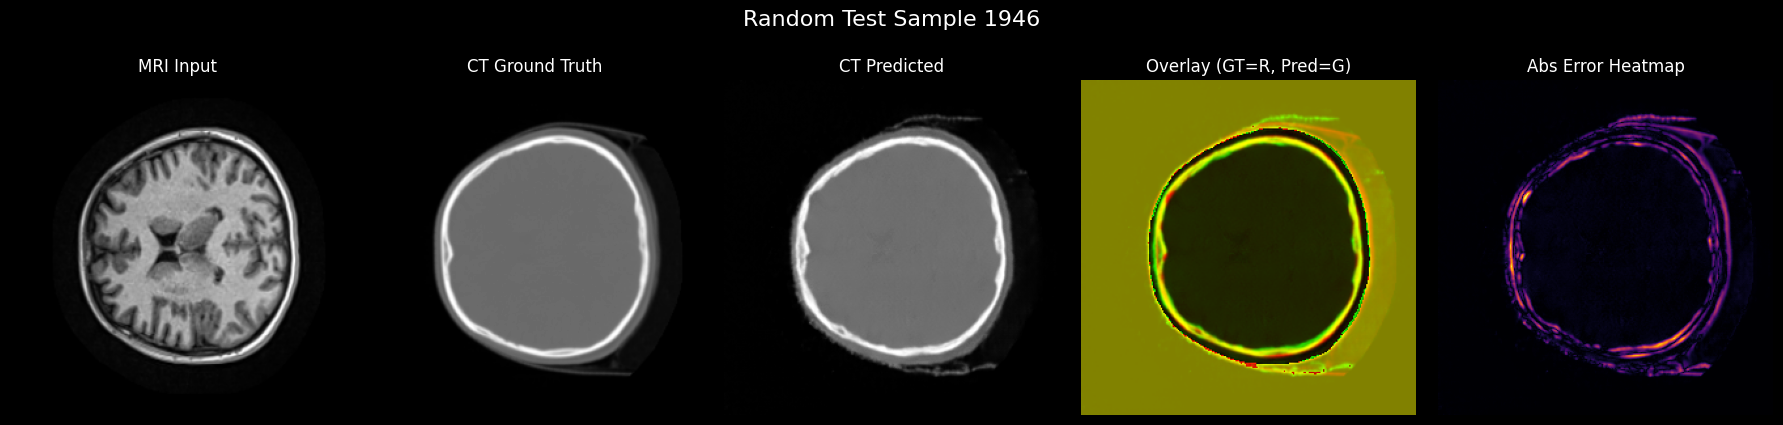

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


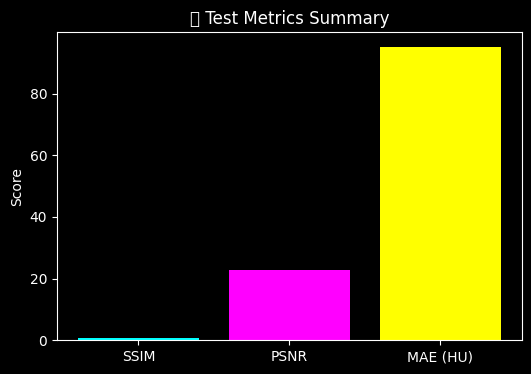

In [20]:
test_results = evaluate_on_test(
    generator,             # use generator only
    test_loader,
    device=device,
    best_model_path=BEST_MODEL_PATH,
    final_model_path=FINAL_MODEL_PATH,
    num_visuals=3          # show 3 samples
)
